In [1]:
# Cell 1 -- Imports and load the trained model
# We load the model we already trained and saved in Step 5, rather than
# retraining -- this notebook is purely for INSPECTING an existing model.
import sys, os
sys.path.append(os.path.abspath("../src"))

import tensorflow as tf
from visualize import get_conv_layer_names, visualize_filters

model = tf.keras.models.load_model("../models/baseline_cnn.keras")
model.summary()

Model: "Interpretable_Fashion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,104 (74.63 KB)

 Trainable params: 6,330 (24.73 KB)

 Non-trainable params: 112 (448.00 B)

 Optimizer params: 12,662 (49.46 KB)

In [2]:
# Cell 2 -- List the conv layers we can inspect
conv_layers = get_conv_layer_names(model)
print("Conv2D layers found:", conv_layers)

Conv2D layers found: ['conv2d', 'conv2d_1', 'conv2d_2']


Layer 'conv2d': 8 filters, each 3x3, operating over 1 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer1.png


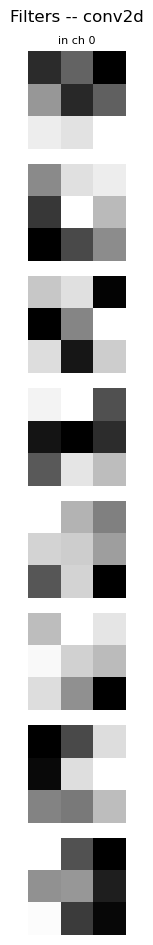

In [3]:
# Cell 3 -- Visualize Layer 1's filters (the directly-interpretable ones)
visualize_filters(model, conv_layers[0], save_path="../reports/figures/filters_layer1.png")

Layer 'conv2d_1': 16 filters, each 3x3, operating over 8 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer2.png


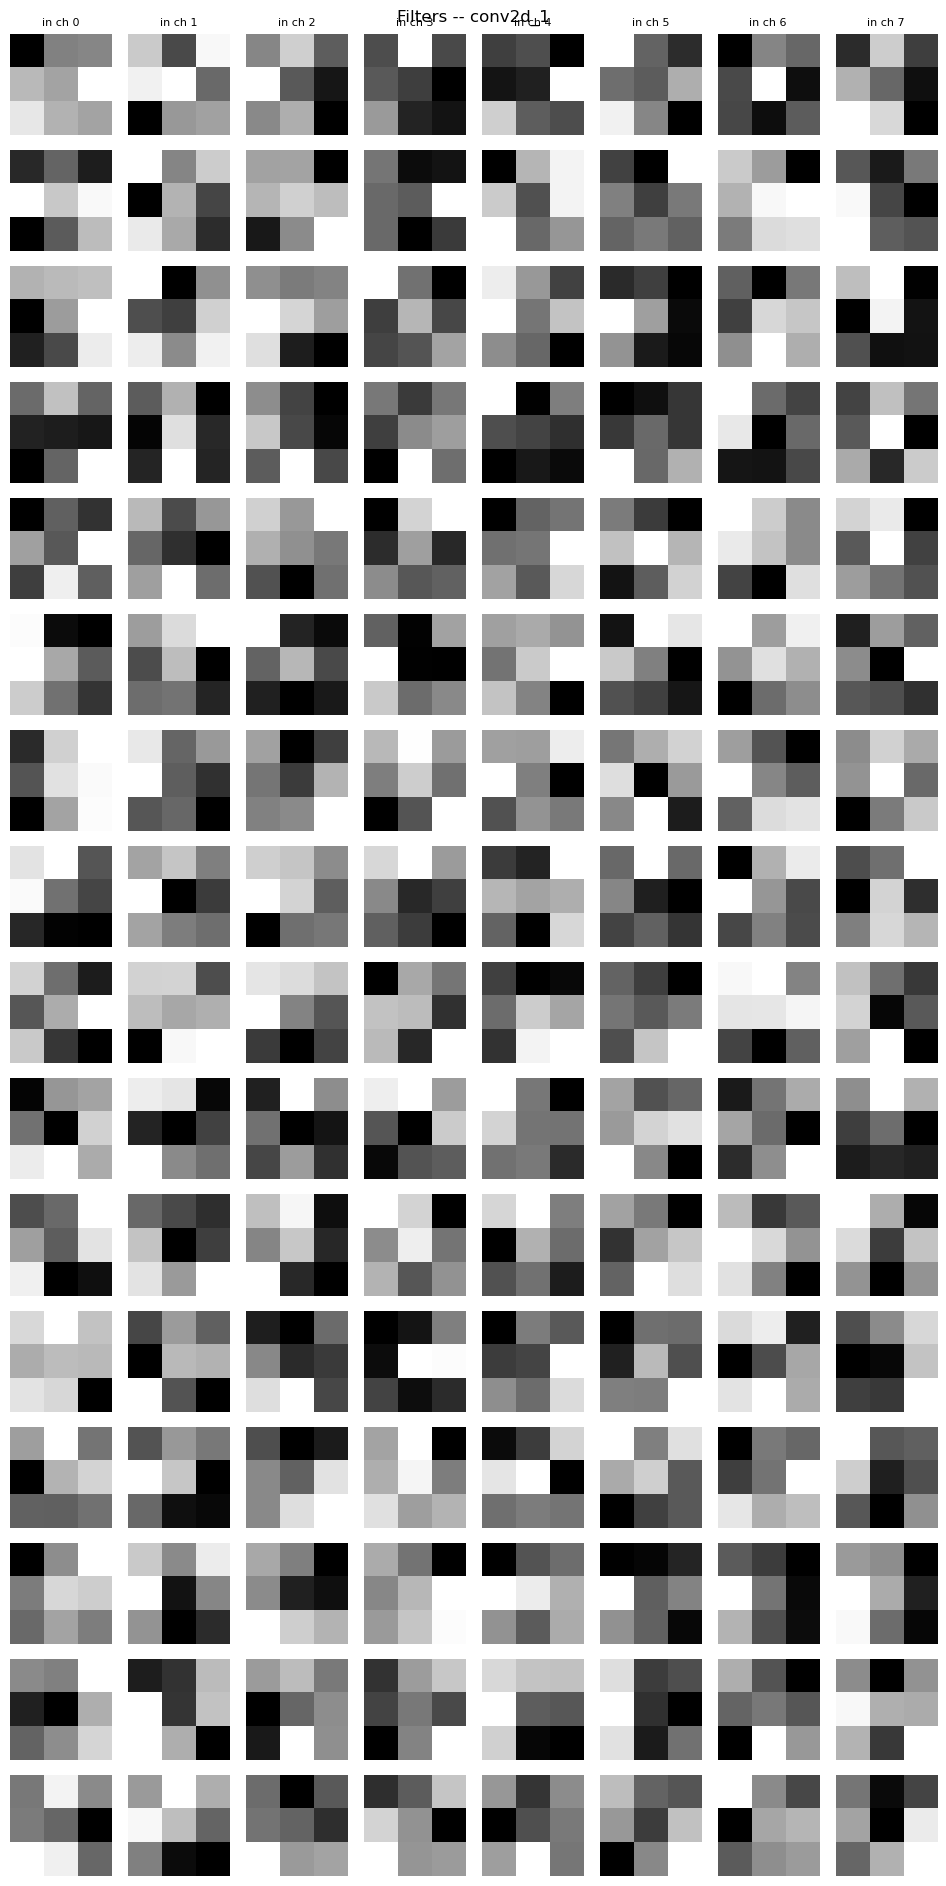

In [4]:
# Cell 4 -- Visualize Layer 2's filters
# Notice this grid is much wider now -- one column per input channel,
# demonstrating that each filter here combines all 8 of layer 1's outputs.
visualize_filters(model, conv_layers[1], save_path="../reports/figures/filters_layer2.png")

Layer 'conv2d_2': 32 filters, each 3x3, operating over 16 input channel(s)
Saved filter visualization to ../reports/figures/filters_layer3.png


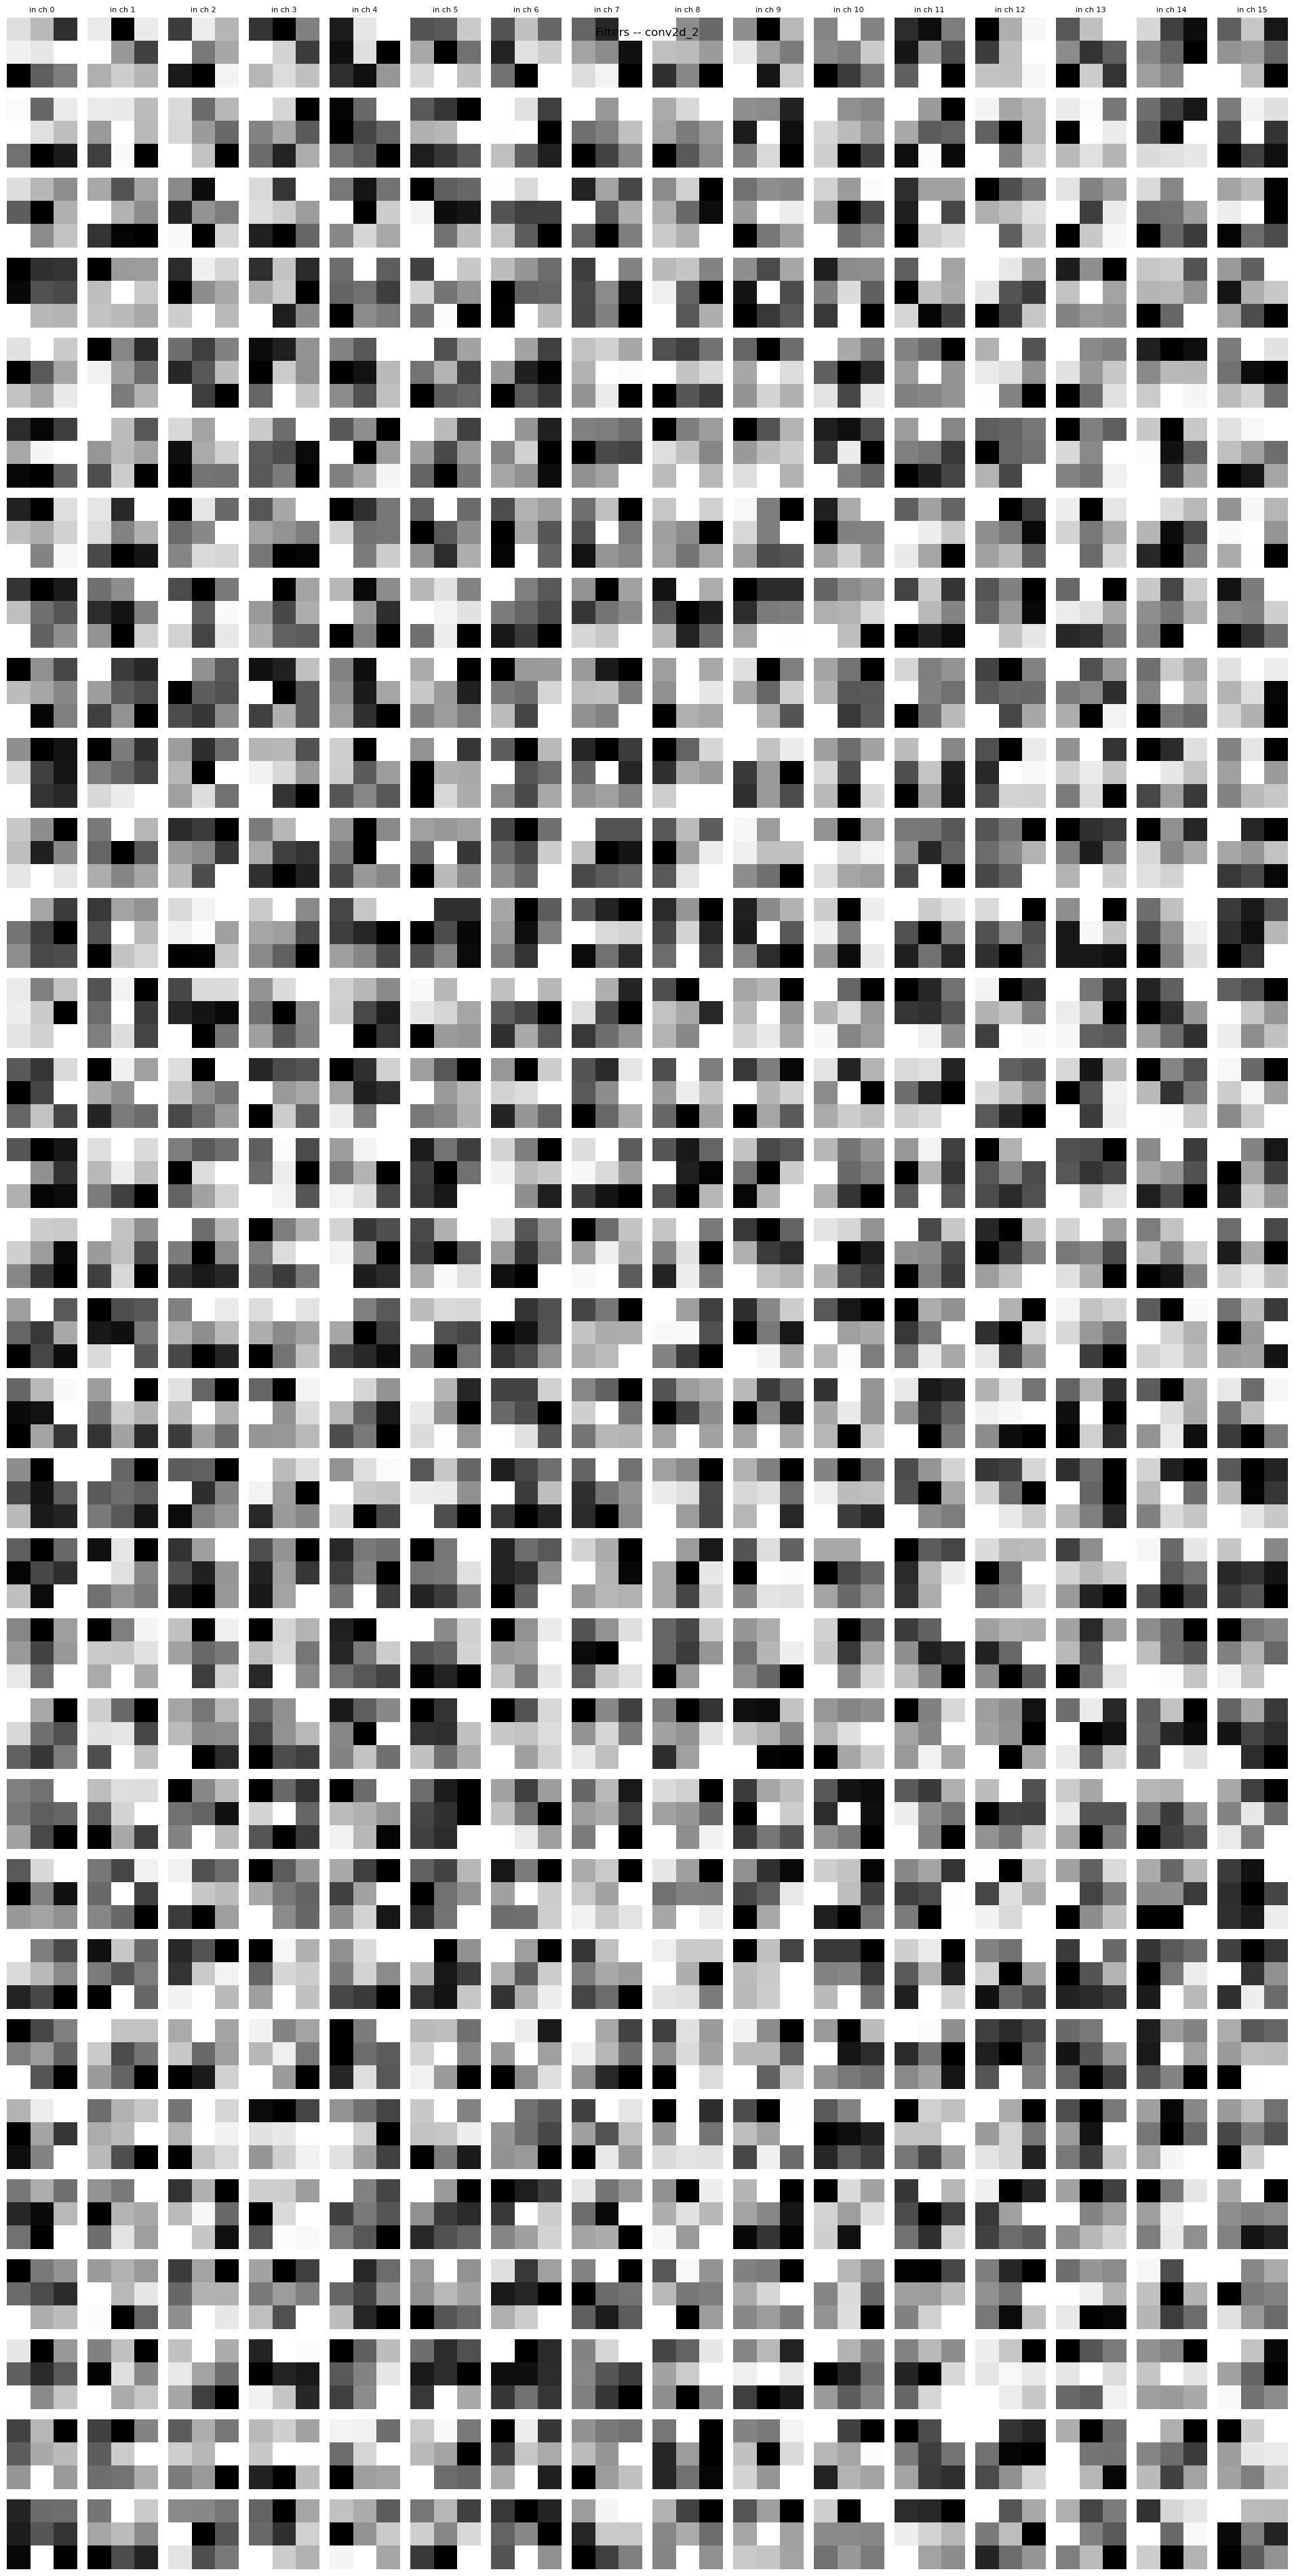

In [5]:
# Cell 5 -- Visualize Layer 3's filters
visualize_filters(model, conv_layers[2], save_path="../reports/figures/filters_layer3.png")

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# Cell 6 -- Feature map visualization: pick one test image to inspect
# We reuse X_test/y_test, so make sure they're loaded in this notebook
# (add this import/load if this notebook doesn't already have it).
from data_prep import load_and_preprocess_data, CLASS_NAMES
from visualize import visualize_feature_maps

_, _, X_test, y_test = load_and_preprocess_data()

# Pick a Shirt image specifically -- Step 5's confusion matrix showed
# this is the model's hardest class, so it's the most interesting one
# to actually look inside.
shirt_indices = np.where(y_test == 6)[0]  # class 6 = "Shirt"
sample_image = X_test[shirt_indices[0]]

print(f"True label: {CLASS_NAMES[y_test[shirt_indices[0]]]}")

Raw shapes -- X_train: (60000, 28, 28), X_test: (10000, 28, 28)
Raw dtype: uint8, raw value range: 0-255
After normalization -- dtype: float32, value range: 0.0-1.0
After reshaping -- X_train: (60000, 28, 28, 1), X_test: (10000, 28, 28, 1)
True label: Shirt


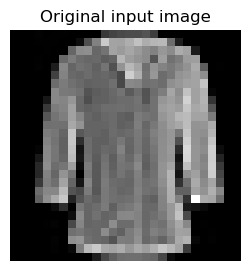


--- conv2d (8 filters) ---
This is the FIRST conv layer -- it sees the raw image directly.
Expect these feature maps to still resemble the original shape,
since each filter is just responding to simple patterns like edges.
0/8 filters barely activated for this image (may be specialized for patterns this image doesn't contain).
Saved feature maps to ../reports/figures/feature_maps_conv2d.png


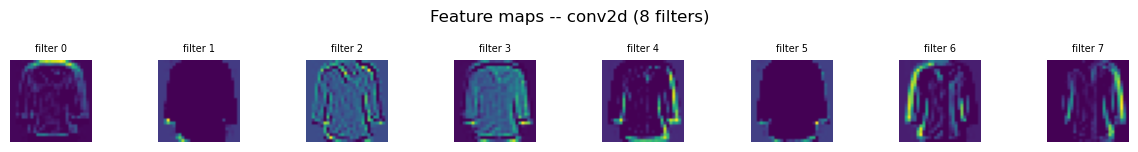


--- conv2d_1 (16 filters) ---
This is a MIDDLE conv layer -- it combines the previous layer's
simple patterns into more complex, but still developing, shapes.
0/16 filters barely activated for this image (may be specialized for patterns this image doesn't contain).
Saved feature maps to ../reports/figures/feature_maps_conv2d_1.png


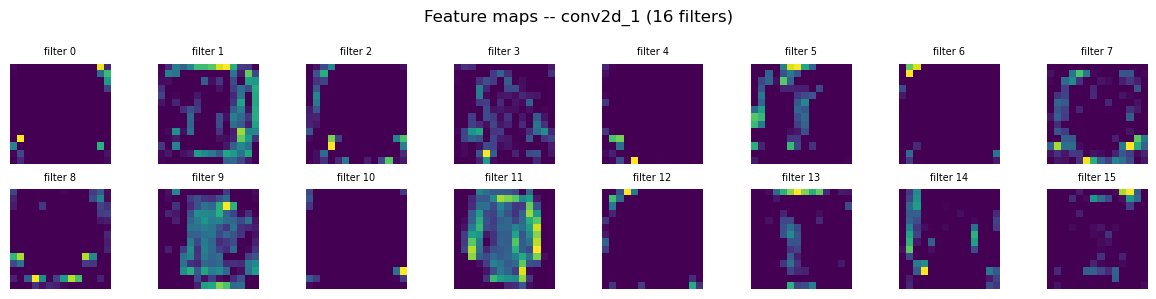


--- conv2d_2 (32 filters) ---
This is the DEEPEST conv layer -- it never sees the raw image,
only combinations of the previous layer's feature maps.
Expect these to look abstract and hard to describe visually.
1/32 filters barely activated for this image (may be specialized for patterns this image doesn't contain).
Saved feature maps to ../reports/figures/feature_maps_conv2d_2.png


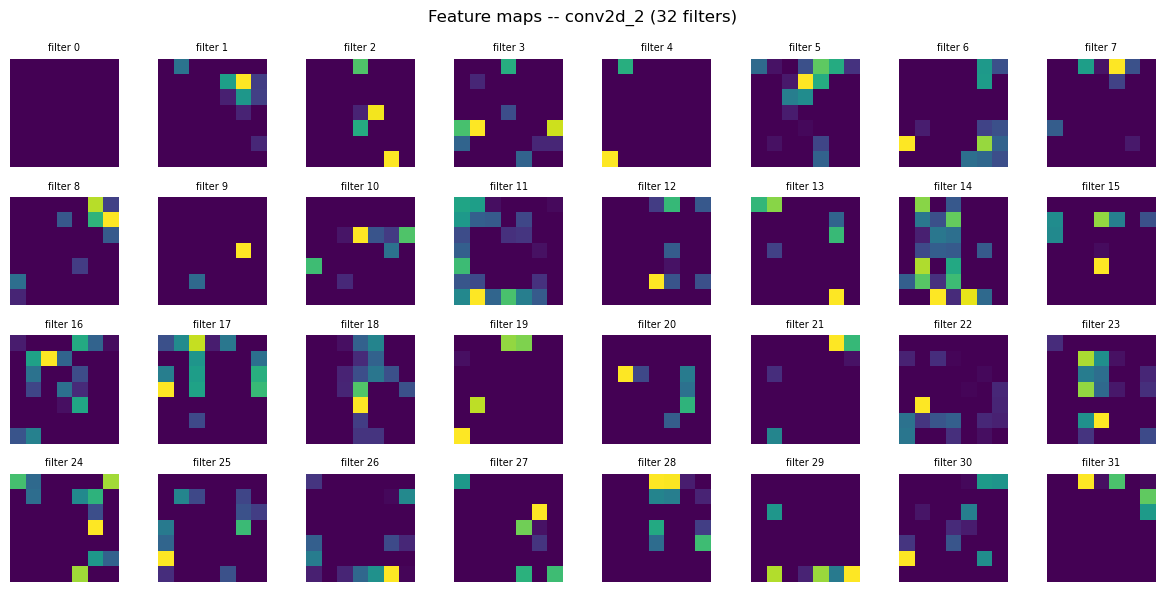

In [8]:
# Cell 7 -- Run the visualization across all 3 conv layers
visualize_feature_maps(model, sample_image, conv_layers, save_path="../reports/figures/feature_maps")